In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/store.csv', low_memory=False)

# Merge
df = train.merge(store, on='Store', how='left')

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Stores: {df['Store'].nunique()}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (1017209, 18)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Stores: 1115
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Missing values:
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [2]:
# Remove closed days
df_open = df[df['Open'] == 1].copy()
df_open = df_open[df_open['Sales'] > 0].copy()

print(f"After removing closed days: {df_open.shape}")
print(f"Sales stats:\n{df_open['Sales'].describe().round(2)}")

After removing closed days: (844338, 18)
Sales stats:
count    844338.00
mean       6955.96
std        3103.82
min          46.00
25%        4859.00
50%        6369.00
75%        8360.00
max       41551.00
Name: Sales, dtype: float64


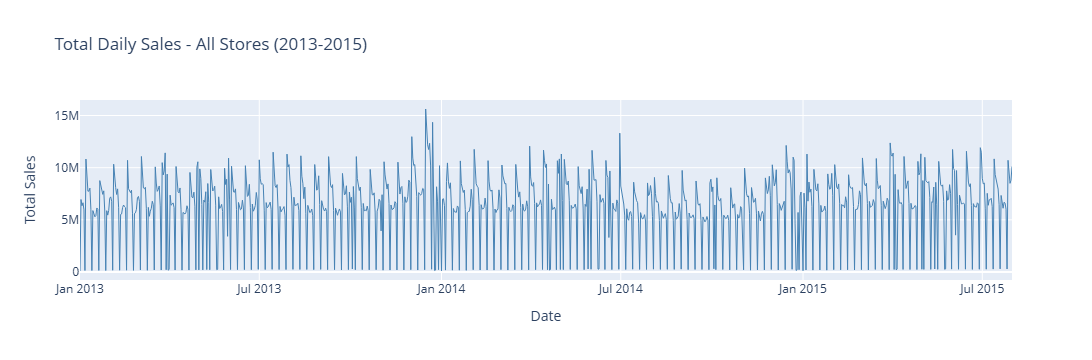

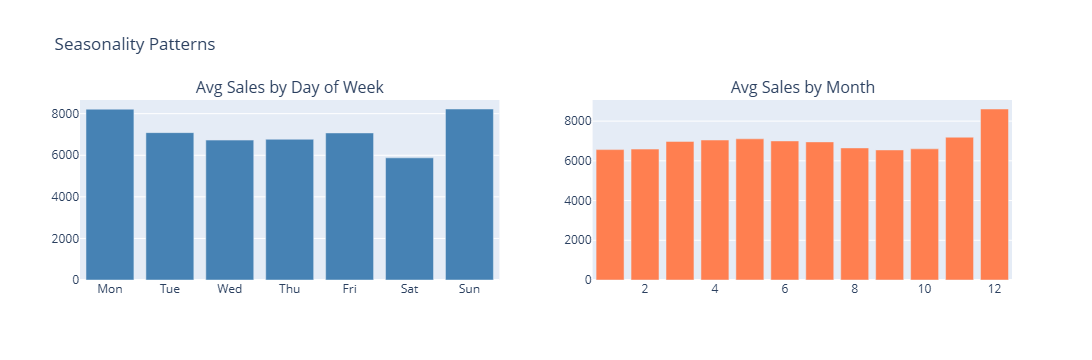

In [4]:
# Day of week pattern
dow_sales = df_open.groupby('DayOfWeek')['Sales'].mean().reset_index()
dow_sales['DayName'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Monthly pattern
df_open['Month'] = df_open['Date'].dt.month
monthly_sales = df_open.groupby('Month')['Sales'].mean().reset_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Avg Sales by Day of Week', 'Avg Sales by Month'])

fig.add_trace(
    go.Bar(x=dow_sales['DayName'], y=dow_sales['Sales'], marker_color='steelblue'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=monthly_sales['Month'], y=monthly_sales['Sales'], marker_color='coral'),
    row=1, col=2
)

fig.update_layout(title='Seasonality Patterns', showlegend=False)
fig.show()

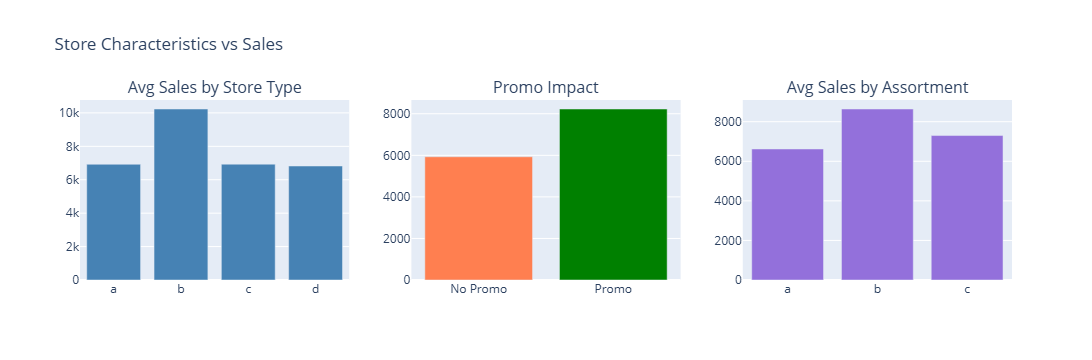

In [5]:
# Sales by store type
storetype_sales = df_open.groupby('StoreType')['Sales'].mean().reset_index()

# Sales with/without promo
promo_sales = df_open.groupby('Promo')['Sales'].mean().reset_index()
promo_sales['Promo'] = promo_sales['Promo'].map({0: 'No Promo', 1: 'Promo'})

# Sales by assortment
assortment_sales = df_open.groupby('Assortment')['Sales'].mean().reset_index()

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Avg Sales by Store Type',
                                    'Promo Impact',
                                    'Avg Sales by Assortment'])

fig.add_trace(
    go.Bar(x=storetype_sales['StoreType'], y=storetype_sales['Sales'],
           marker_color='steelblue'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=promo_sales['Promo'], y=promo_sales['Sales'],
           marker_color=['coral', 'green']),
    row=1, col=2
)

fig.add_trace(
    go.Bar(x=assortment_sales['Assortment'], y=assortment_sales['Sales'],
           marker_color='mediumpurple'),
    row=1, col=3
)

fig.update_layout(title='Store Characteristics vs Sales', showlegend=False)
fig.show()

Store 1 rows: 781
Date range: 2013-01-02 00:00:00 to 2015-07-31 00:00:00
Avg Sales: 4759
Store Type: c
Assortment: a


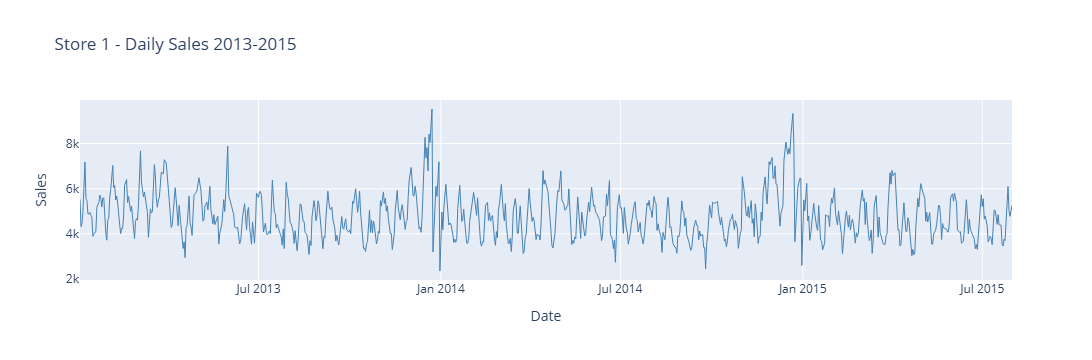

In [6]:
# Single store analysis - Store 1
store1 = df_open[df_open['Store'] == 1].sort_values('Date').copy()

print(f"Store 1 rows: {len(store1)}")
print(f"Date range: {store1['Date'].min()} to {store1['Date'].max()}")
print(f"Avg Sales: {store1['Sales'].mean():.0f}")
print(f"Store Type: {store1['StoreType'].iloc[0]}")
print(f"Assortment: {store1['Assortment'].iloc[0]}")

fig = px.line(
    store1,
    x='Date',
    y='Sales',
    title='Store 1 - Daily Sales 2013-2015',
    labels={'Sales': 'Sales', 'Date': 'Date'}
)
fig.update_traces(line_color='steelblue', line_width=1)
fig.update_layout(hovermode='x unified')
fig.show()

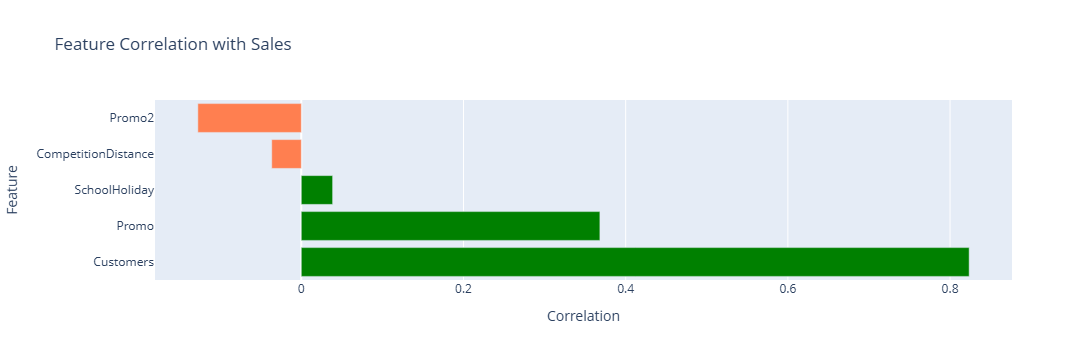


Correlation values:
Customers              0.824
Promo                  0.368
SchoolHoliday          0.039
CompetitionDistance   -0.036
Promo2                -0.128
Name: Sales, dtype: float64


In [7]:
# Correlation of numeric features with Sales
numeric_cols = ['Sales', 'Customers', 'Promo', 'SchoolHoliday',
                'CompetitionDistance', 'Promo2']

corr = df_open[numeric_cols].corr()['Sales'].drop('Sales').sort_values(ascending=False)

fig = go.Figure(go.Bar(
    x=corr.values,
    y=corr.index,
    orientation='h',
    marker_color=['green' if v > 0 else 'coral' for v in corr.values]
))

fig.update_layout(
    title='Feature Correlation with Sales',
    xaxis_title='Correlation',
    yaxis_title='Feature'
)
fig.show()

print("\nCorrelation values:")
print(corr.round(3))